If we're only comparing IBM to a meshed case, it makes more sense to make pretty pictures in a notebook.
Hopefully the best cases will slot in here nicely:

In [1]:
# to be changed to the correct paths of the nicest looking IBM
meshed_case = 'meshed_mesh_2_re_200'
IBM_case = 'brinkman_mesh_2_re_200_chi_1000_radius_0-05'

# To be changed to the correct path once you have the stats files!
results_path = "../../../results/statistics/brinkman_parameters/cases/"
brinkman_path = "brinkman_mesh_2_re_200_chi_100_radius_0-05/"
meshed_path = "meshed_mesh_4_re_200/"

In [2]:
import os                                                                       
import sys                                                                      
                                                                                
# Local imports                                                                 
from metrics import *                                                           
from functions.readers import experiment_reader                                 
from experiments import *                                                       
                                                                                
# Define useful paths for the script                                            
current_dir = os.getcwd()                     
root_dir = os.path.abspath(os.path.join(current_dir, "../../.."))                                                 
cases_dir = os.path.join(root_dir, "results", "brinkman_parameters", "cases")
plots_dir = os.path.abspath(os.path.join(current_dir, "../", "plots"))
cache_dir = os.path.join(root_dir, "results", "brinkman_parameters", "cache")

meshed_dir = os.path.join(cases_dir, meshed_case)
IBM_dir = os.path.join(cases_dir, IBM_case)

plot_params = {                                                                 
    # Settings for post processing                                              
    # Lift and drag                                                             
    "if_lift_and_drag": True,                                                   
    "lift_axis": [-1, 1],  # axis for plotted lift,                             
    "drag_axis": [0, 1.5],  # axis for plotted drag,                            
    # Statistics interpolation (wake deficit)                                   
    "if_stats_wake": True,                                                      
    "wake_y_lim": [-15, 15],  # y limits for wake profiles,                     
    "wake_n_pts": 300,  # number points in the wake,                            
    "wake_positions": [10, 15, 20],  # position for wakes,                      
    "wake_U_lim": [0.5, 1.2],  # axis limits for wakes plot,                    
    # Statistics interpolation (force rings)                                    
    "if_stats_force": True,                                                     
    "force_n_pts": 360,  # number of interpolation points,                      
    "force_ring_radii": ["050", "0501", "0502", "0505", "051", "052", "055"],   
    # rings to consider (in the statistics!)                                    
    "force_ring_plot": [0.5, 0.532],                                            
    # rings to consider (in the time series!)                                   
    "force_ring_plot_time": ["051"],                                            
    # rings to plot                                                             
    # For taking averages of time series                                        
    "t_start": 100.0  # time to start averaging,                                
}

# Lift, drag, separation angle

In [3]:
# for the meshed case read the probes
file_name = os.path.join(meshed_dir, 'cylinder.log')
meshed_LD = read_force_torque(file_name, cache_dir)
# sep angle
file_name = os.path.join(meshed_dir, 'circ_051.csv') 
meshed_theta = inflection_benchmark(file_name, cache_dir)
# mean/amps
meshed_mean_L, meshed_amp_L = mean_and_amp(meshed_LD["t"], meshed_LD["fy_tot"], 100)
meshed_mean_D, meshed_amp_D = mean_and_amp(meshed_LD["t"], meshed_LD["fx_tot"], 100)
meshed_mean_t, meshed_amp_t = mean_and_amp(meshed_theta["times"], 180.0 - np.rad2deg(meshed_theta["angles"][:,0]), 100)
meshed_St = np.mean(meshed_theta['max_freq'])

# for IBM take a ring
file_name = os.path.join(IBM_dir, 'circ_050.csv')             
IBM_LD = surface_integral_lift_and_drag(file_name, 200.0, cache_dir)
file_name = os.path.join(IBM_dir, 'circ_051.csv')
# sep angle
IBM_theta = inflection_benchmark(file_name, cache_dir)
# mean/amps
IBM_mean_L, IBM_amp_L = mean_and_amp(IBM_LD["t"], IBM_LD["fy_tot"], 100)
IBM_mean_D, IBM_amp_D = mean_and_amp(IBM_LD["t"], IBM_LD["fx_tot"], 100)
IBM_mean_t, IBM_amp_t = mean_and_amp(IBM_theta["times"], 180.0 - np.rad2deg(IBM_theta["angles"][:,0]), 100)
IBM_St = np.mean(IBM_theta['max_freq'])

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


 Meshed & -0.009 & 0.682 & 1.340 & 0.045 & 114.413 & 6.225 & 0.200 \\
 IBM & 0.006 & 0.170 & 0.959 & 0.011 & 165.615 & 179.749 & 0.130 \\
 Difference & -173.6\%  & -75.1\%  & 68.3\%  & -75.6\%  & 139.3\%  & 2787.6\%  & -35.1\%  \\


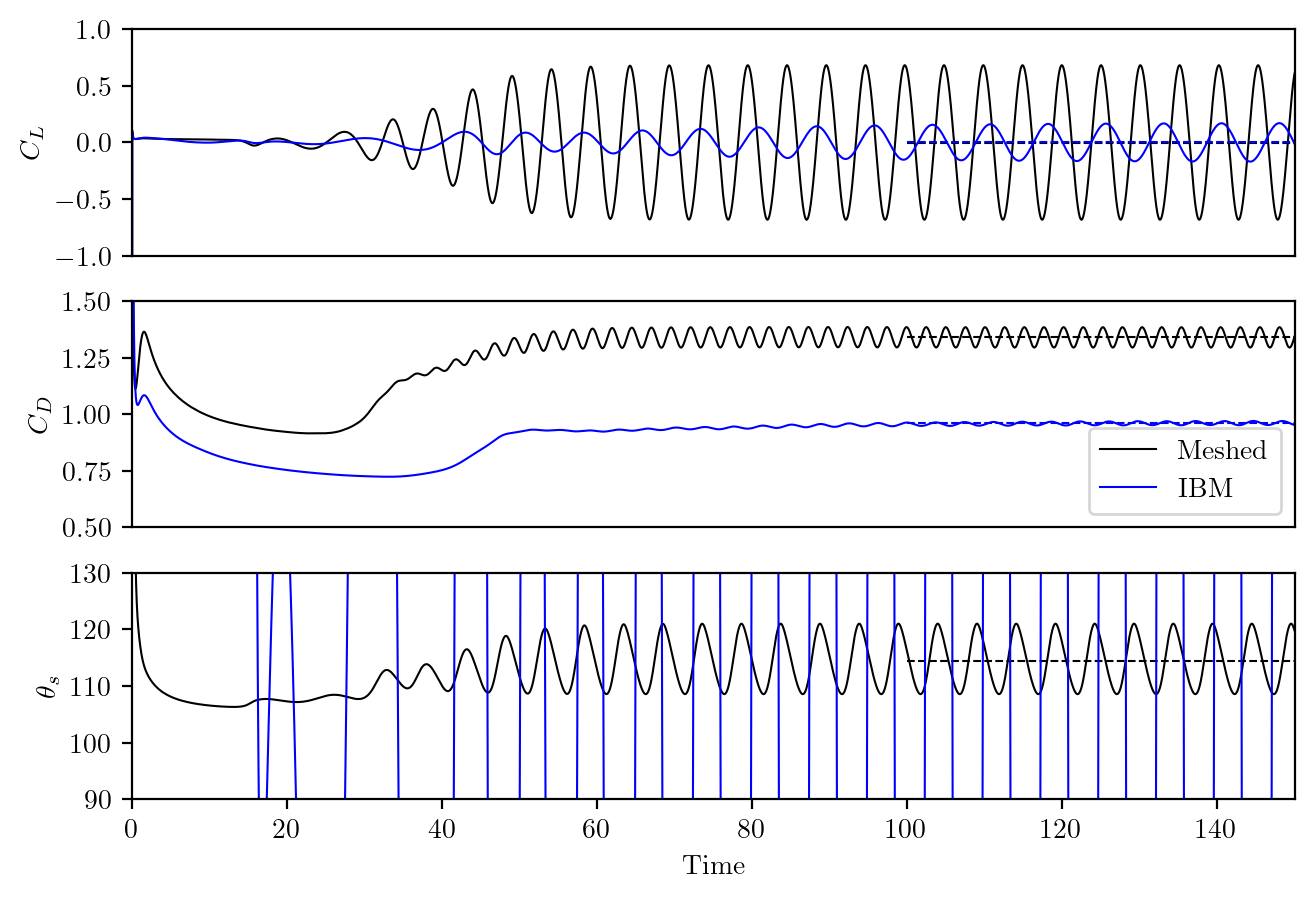

In [4]:
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 0.75


fig, ax = plt.subplots(3,1, figsize=(7.5, 5), dpi = 200)
# Meshed
ax[0].plot(meshed_LD["t"], meshed_LD["fy_tot"]*2, '-k', label =  "Meshed")
ax[0].plot([100, 150], [meshed_mean_L*2, meshed_mean_L*2], '--k')
ax[1].plot(meshed_LD["t"], meshed_LD["fx_tot"]*2, '-k', label =  "Meshed")
ax[1].plot([100, 150], [meshed_mean_D*2, meshed_mean_D*2], '--k')
ax[2].plot(meshed_theta["times"], 180.0 - np.rad2deg(meshed_theta["angles"][:,0]), '-k', label =  "Meshed")
ax[2].plot([100, 150], [meshed_mean_t, meshed_mean_t], '--k')
# IBM
ax[0].plot(IBM_LD["t"], IBM_LD["fy_tot"]*2, '-b', label =  "IBM")
ax[0].plot([100, 150], [IBM_mean_L*2, IBM_mean_L*2], '--b')
ax[1].plot(IBM_LD["t"], IBM_LD["fx_tot"]*2, '-b', label =  "IBM")
ax[1].plot([100, 150], [IBM_mean_D*2, IBM_mean_D*2], '--b')
ax[2].plot(IBM_theta["times"], 180.0 - np.rad2deg(IBM_theta["angles"][:,0]), '-b', label =  "IBM")
ax[2].plot([100, 150], [IBM_mean_t, IBM_mean_t], '--b')

                                       
ax[0].set_ylabel("$C_L$")                                                    
ax[1].set_ylabel("$C_D$")                                                    
ax[0].set_ylim([-1, 1])                                                   
ax[1].set_ylim([0.5, 1.5])   
ax[2].set_ylim([90, 130])

ax[0].set_xlim([0, 150])      
ax[1].set_xlim([0, 150])  
ax[2].set_xlim([0, 150])  

ax[0].set_xticks([])
ax[1].set_xticks([])

ax[2].set_ylabel(r"$\theta_s$")                                               
ax[1].legend()                                                              
ax[2].set_xlabel("Time")  

fig.savefig(plots_dir + '/report_LDt.eps')


print(' Meshed & ' + f'{meshed_mean_L*2:.3f}' + ' & ' + f'{meshed_amp_L*2:.3f}'
    + ' & ' + f'{meshed_mean_D*2:.3f}' + ' & ' + f'{meshed_amp_D*2:.3f}'
    + ' & ' + f'{meshed_mean_t:.3f}' + ' & ' + f'{meshed_amp_t:.3f}'
    + ' & ' + f'{meshed_St:.3f}' + ' \\\\')
print(' IBM & ' + f'{IBM_mean_L*2:.3f}' + ' & ' + f'{IBM_amp_L*2:.3f}'
    + ' & ' + f'{IBM_mean_D*2:.3f}' + ' & ' + f'{IBM_amp_D*2:.3f}'
    + ' & ' + f'{IBM_mean_t:.3f}' + ' & ' + f'{IBM_amp_t:.3f}'
    + ' & ' + f'{IBM_St:.3f}' + ' \\\\')
print(' Difference & ' + f'{(IBM_mean_L - meshed_mean_L)/meshed_mean_L*100:.1f}' 
    + '\%  & ' + f'{(IBM_amp_L - meshed_amp_L)/meshed_amp_L*100:.1f}'
    + '\%  & ' + f'{(IBM_mean_D - meshed_amp_D)/meshed_mean_D*100:.1f}'
    + '\%  & ' + f'{(IBM_amp_D - meshed_amp_D)/meshed_amp_D*100:.1f}'
    + '\%  & ' + f'{(IBM_mean_t - meshed_amp_t)/meshed_mean_t*100:.1f}'
    + '\%  & ' + f'{(IBM_amp_t - meshed_amp_t)/meshed_amp_t*100:.1f}'
    + '\%  & ' + f'{(IBM_St - meshed_St)/meshed_St*100:.1f}'
    + '\%  \\\\')

# Statistics files
I actually think the top two plots would look better with an instantious snapshot of the vorticity!

In [5]:
import os
os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
import matplotlib.pyplot as plt
import numpy as np
from pynektools.datatypes.field import FieldRegistry




stats_file = "fluid_stats0"
# stats_file = "field0"
meshed = {}
IBM = {}
meshed["name"] = 'meshed'
IBM["name"] = 'IBM'


# IBM
file_name = results_path + brinkman_path + stats_file + '/' + stats_file
IBM["mesh"], IBM["fld"] = load_stats_file(file_name, 2)

# Meshed
file_name = results_path + meshed_path + stats_file + '/' + stats_file
meshed["mesh"], meshed["fld"] = load_stats_file(file_name, 2)

In [6]:
meshed_wake_line = wake(meshed_dir, plot_params, cache_dir)
IBM_wake_line = wake(IBM_dir, plot_params, cache_dir)

from matplotlib.gridspec import GridSpec

#constrained_layout=True
fig = plt.figure( figsize=(7.5, 7.5), dpi = 200)
gs = GridSpec(3, 3, figure=fig)

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, :])
ax2 = fig.add_subplot(gs[2, 0])
ax3 = fig.add_subplot(gs[2, 1])
ax4 = fig.add_subplot(gs[2, 2])

c = ax0.tricontourf(IBM["mesh"].x.flatten(), IBM["mesh"].y.flatten() ,IBM["fld"].registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
cbar = fig.colorbar(c, ax = [ax0, ax1])
cbar.set_label(r'$\bar{u}$')
ax0.set_aspect('equal')
ax0.set_xticks([])
ax0.set_yticks([])
ax0.set_ylim([-10, 10])
ax0.plot([10, 10], [-10, 10], '--k')
ax0.text(-14, 8, "IBM",backgroundcolor='w', horizontalalignment = 'left')
ax0.text(10, 8, r"$x = 10D$",backgroundcolor='w', horizontalalignment = 'center')
ax0.text(20, 8, r"$x = 20D$",backgroundcolor='w', horizontalalignment = 'center')
ax0.text(15, -8.5, r"$x = 15D$",backgroundcolor='w', horizontalalignment = 'center')
ax0.plot([15, 15], [-10, 10], '--k')
ax0.plot([20, 20], [-10, 10], '--k')
c = ax1.tricontourf(meshed["mesh"].x.flatten(), meshed["mesh"].y.flatten() ,meshed["fld"].registry["u"].flatten(), levels=np.arange(start=-0.5, stop=1.5, step=0.01), cmap="RdBu_r")
ax1.plot([10, 10], [-10, 10], '--k')
ax1.plot([15, 15], [-10, 10], '--k')
ax1.plot([20, 20], [-10, 10], '--k')
ax1.text(-14, 8, "Meshed",backgroundcolor='w', horizontalalignment = 'left')
ax1.set_aspect('equal')
ax1.set_ylim([-10, 10])
ax1.set_xticks([])
ax1.set_yticks([]) 

wake_index = np.where(meshed_wake_line["wake_xyz"][:,0] == 10)
ax2.plot(meshed_wake_line["wake_u"][0,:].flatten(), meshed_wake_line["wake_xyz"][wake_index, 1].flatten(), '-k', label="Meshed")
ax2.plot(IBM_wake_line["wake_u"][0,:].flatten(), IBM_wake_line["wake_xyz"][wake_index, 1].flatten(),'-b', label="IBM")
wake_index = np.where(meshed_wake_line["wake_xyz"][:,0] == 15)
ax3.plot(meshed_wake_line["wake_u"][0,:].flatten(), meshed_wake_line["wake_xyz"][wake_index, 1].flatten(), '-k', label="Meshed")
ax3.plot(IBM_wake_line["wake_u"][0,:].flatten(), IBM_wake_line["wake_xyz"][wake_index, 1].flatten(),'-b', label="IBM")
wake_index = np.where(meshed_wake_line["wake_xyz"][:,0] == 20)
ax4.plot(meshed_wake_line["wake_u"][0,:].flatten(), meshed_wake_line["wake_xyz"][wake_index, 1].flatten(), '-k', label="Meshed")
ax4.plot(IBM_wake_line["wake_u"][0,:].flatten(), IBM_wake_line["wake_xyz"][wake_index, 1].flatten(),'-b', label="IBM")


ax2.set_xlim([0.5, 1.1])
ax3.set_xlim([0.5, 1.1])
ax4.set_xlim([0.5, 1.1])
ax2.set_ylim([-5, 5])
ax3.set_ylim([-5, 5])
ax4.set_ylim([-5, 5])

ax3.set_yticks([])
ax4.set_yticks([])

ax2.set_title(r'$x = 10D$')
ax3.set_title(r'$x = 15D$')
ax4.set_title(r'$x = 20D$')

ax2.set_xlabel(r"$\bar{u}$") 
ax2.set_ylabel(r"$y/D$")
ax3.set_xlabel(r"$\bar{u}$")
ax4.set_xlabel(r"$\bar{u}$")
ax4.legend()  


plt.show()

fig.savefig(plots_dir + '/report_wake_deficit.png')
fig.savefig(plots_dir + '/report_wake_deficit.eps')

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/nobis/POSTDOC/NEKO_TOP/neko-top/results/brinkman_parameters/cases/meshed_mesh_2_re_200/fluid_stats0/fluid_stats0.f00000'

Ok this one didn't make it into the post processing script so there's no cache for this

In [ ]:
def calculate_forces(msh, fld, ring_radii, n_points, Re):
    from mpi4py import MPI #equivalent to the use of MPI_init() in C
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry

    # Hide the log for the notebook. Not recommended when running in clusters as it is better you see what happens
    import os
    os.environ["PYNEKTOOLS_HIDE_LOG"] = 'true'
    
    from pynektools.io.ppymech.neksuite import pynekread
    from pynektools.datatypes.msh import Mesh
    from pynektools.datatypes.coef import Coef
    from pynektools.datatypes.field import FieldRegistry
    from pynektools.postprocessing.file_indexing import index_files_from_folder

    from pynektools.interpolation.probes import Probes
    import pynektools.interpolation.utils as interp_utils
    import pynektools.interpolation.pointclouds as pcs

    # Get mpi info
    comm = MPI.COMM_WORLD
    
    # compute derivatives
    coef = Coef(msh, comm, get_area=False)
    dudx = coef.dudxyz(fld.registry['u'], coef.drdx, coef.dsdx, coef.dtdx)
    dudy = coef.dudxyz(fld.registry['u'], coef.drdy, coef.dsdy, coef.dtdx)
    dvdx = coef.dudxyz(fld.registry['v'], coef.drdx, coef.dsdx, coef.dtdx)
    dvdy = coef.dudxyz(fld.registry['v'], coef.drdy, coef.dsdy, coef.dtdx)

    # It's probably best to take a good z location so we don't get fucked interpolation between z coords
    z_GLL = np.unique(msh.z)

    # set up probes
    if comm.Get_rank() == 0 :
    
        # Generate the 1D mesh
        r_1d = np.array(ring_radii)
        th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal")
        z_1d = np.array([z_GLL[2]])
    
        # Generate a 3D mesh
        r, th, z = np.meshgrid(r_1d, th_1d, z_1d, indexing='ij')
        x = r*np.cos(th)
        y = r*np.sin(th)
    
        # Array the points as a list of probes
        xyz = interp_utils.transform_from_array_to_list(len(ring_radii),n_points,1,[x, y, z])
    
    else:
        xyz = None
    
    
    # This sets up the probes interpolation
    ring_probes = Probes(comm, probes = xyz, msh = msh, point_interpolator_type='multiple_point_legendre_numpy', \
                             max_pts=256, find_points_comm_pattern='point_to_point')
    
    # here we actually probe
    ring_probes.interpolate_from_field_list(0, [dudx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dudy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dudy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdx], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdx = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [dvdy], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    dvdy = np.copy(int_fields[1])
    
    ring_probes.interpolate_from_field_list(0, [fld.registry['p']], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    p = np.copy(int_fields[1])

    ring_probes.interpolate_from_field_list(0, [fld.registry['t']], comm, write_data=False)
    int_fields = interp_utils.transform_from_list_to_array(len(ring_radii),n_points,1,ring_probes.interpolated_fields)
    pp = np.copy(int_fields[1])
    
    f_x_visc = np.zeros((len(ring_radii), n_points))
    f_y_visc = np.zeros((len(ring_radii), n_points))
    f_x_p    = np.zeros((len(ring_radii), n_points))
    f_y_p    = np.zeros((len(ring_radii), n_points))
    f_x_tot  = np.zeros((len(ring_radii), n_points))
    f_y_tot  = np.zeros((len(ring_radii), n_points))
    p_rms    = np.zeros((len(ring_radii), n_points))
    
    f_x_visc_int = np.zeros((len(ring_radii)))
    f_y_visc_int = np.zeros((len(ring_radii)))
    f_x_p_int    = np.zeros((len(ring_radii)))
    f_y_p_int    = np.zeros((len(ring_radii)))
    f_x_tot_int  = np.zeros((len(ring_radii)))
    f_y_tot_int  = np.zeros((len(ring_radii)))
    
    for i in range(len(ring_radii)):
        for j in range(n_points):
            # viscous
            f_x_visc[i,j] = ( dudx[i,j] * 2          * np.cos(th_1d[j]) + 
                             (dudy[i,j] + dvdx[i,j]) * np.sin(th_1d[j]))/Re
            f_y_visc[i,j] = ((dudy[i,j] + dvdx[i,j]) * np.cos(th_1d[j]) + 
                              dvdy[i,j] * 2          * np.sin(th_1d[j]))/Re
            
            #pressure
            f_x_p[i,j] = -p[i,j] * np.cos(th_1d[j])
            f_y_p[i,j] = -p[i,j] * np.sin(th_1d[j])

            # total
            f_x_tot[i,j] = f_x_visc[i,j] + f_x_p[i,j]
            f_y_tot[i,j] = f_y_visc[i,j] + f_y_p[i,j]

            # p rms
            p_rms[i,j] = np.sqrt(np.abs(pp[i,j] - p[i,j]*p[i,j]))
        

    # Here we integrate them around to get a single number
    for i in range(len(ring_radii)):
        ri1 = (n_points)*i
        ri2 = (n_points )*(i+1)
        dS = (2 * np.pi * ring_radii[i]) / n_points
        
        f_x_visc_int[i] = np.sum(f_x_visc[i,:]) * dS
        f_y_visc_int[i] = np.sum(f_y_visc[i,:]) * dS
        f_x_p_int[i]    = np.sum(f_x_p[i,:]) * dS
        f_y_p_int[i]    = np.sum(f_y_p[i,:]) * dS
        
        f_x_tot_int[i] = f_x_visc_int[i] + f_x_p_int[i]
        f_y_tot_int[i] = f_y_visc_int[i] + f_y_p_int[i]

        force_measure = {}
        force_measure["fx_tot"] = f_x_tot
        force_measure["fx_p"] = f_x_p
        force_measure["fx_visc"] = f_x_visc
        force_measure["fy_tot"] = f_y_tot
        force_measure["fy_p"] = f_y_p
        force_measure["fy_visc"] = f_y_visc
        force_measure["fx_tot_int"] = f_x_tot_int
        force_measure["fx_p_int"] = f_x_p_int
        force_measure["fx_visc_int"] = f_x_visc_int
        force_measure["fy_tot_int"] = f_y_tot_int
        force_measure["fy_p_int"] = f_y_p_int
        force_measure["fy_visc_int"] = f_y_visc_int
        force_measure["p"] = p
        force_measure["p_rms"] = p_rms
        force_measure["ring"] = ring_radii

    return force_measure

In [ ]:
ring_radii = [0.50]
n_points = 360
Re = 200.0

IBM["stats_forces"] = calculate_forces(IBM["mesh"], IBM["fld"], ring_radii, n_points, Re)
meshed["stats_forces"] = calculate_forces(meshed["mesh"], meshed["fld"], ring_radii, n_points, Re)
case_list = [IBM, meshed]



In [ ]:
import pynektools.interpolation.pointclouds as pcs
th_1d = pcs.generate_1d_arrays([0, 2*np.pi], n_points, mode="equal") 

fig, ax = plt.subplots(1, 2, figsize=(7.5, 3), dpi = 200)
ring_index = np.where(np.array(meshed["stats_forces"]["ring"]) == 0.50)

meshed_Cp = meshed["stats_forces"]["p"][ring_index,:].flatten()*2
IBM_Cp = IBM["stats_forces"]["p"][ring_index,:].flatten()*2
ax[0].plot(th_1d/np.pi*180 -180, meshed_Cp,'-k', label="Meshed")
ax[0].plot(th_1d/np.pi*180 -180, IBM_Cp,'-b', label="IBM")
ax[0].set_xlabel(r'$\theta$')
ax[0].set_ylabel(r'$C_p$')
ax[0].set_xlim([0, 180])
ax[0].set_ylim([-1.5, 1.2])

meshed_Cp = meshed["stats_forces"]["p_rms"][ring_index,:].flatten()*2
IBM_Cp = IBM["stats_forces"]["p_rms"][ring_index,:].flatten()*2
ax[1].plot(th_1d/np.pi*180 -180, meshed_Cp,'-k', label="Meshed")
ax[1].plot(th_1d/np.pi*180 -180, IBM_Cp,'-b', label="IBM")
ax[1].set_xlabel(r'$\theta$')
ax[1].set_ylabel(r'$C_{p\prime}$')
ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")
ax[1].legend()
ax[1].set_xlim([0, 180])
ax[1].set_ylim([0, 0.3])

fig.savefig(plots_dir + '/report_avg_p_dist.eps')
fig.savefig(plots_dir + '/report_avg_p_dist.png')
